# Data Generation

**No need to change anything here in this section**

Understand the structure of the data and also you might get some hint from this part of code.

**Best of luck**

   DHAKA CAKE SELLER MANAGEMENT SYSTEM  

Initializing system... Generating cake seller data...
Generated 100 cake sellers at random locations
Loaded city road network with 15 nodes

SAMPLE CAKE SELLER DATA (First 10)

 1. CAKE-001 - Hygiene:  80/100 | Experience:  4 yrs | Revenue: ৳16,639
    Location: (23.8097, 90.3598)

 2. CAKE-002 - Hygiene:  48/100 | Experience:  4 yrs | Revenue: ৳59,348
    Location: (23.8096, 90.3718)

 3. CAKE-003 - Hygiene:  77/100 | Experience: 14 yrs | Revenue: ৳17,082
    Location: (23.7812, 90.3587)

 4. CAKE-004 - Hygiene:  72/100 | Experience: 20 yrs | Revenue: ৳16,739
    Location: (23.8024, 90.3786)

 5. CAKE-005 - Hygiene:  84/100 | Experience: 18 yrs | Revenue: ৳42,493
    Location: (23.7888, 90.3736)

 6. CAKE-006 - Hygiene:  91/100 | Experience:  1 yrs | Revenue: ৳25,463
    Location: (23.8079, 90.3636)

 7. CAKE-007 - Hygiene:  49/100 | Experience:  7 yrs | Revenue: ৳37,059
    Location: (23.7841, 90.3652)

 8. CAKE-008 - Hygiene:  62/100 | Exper

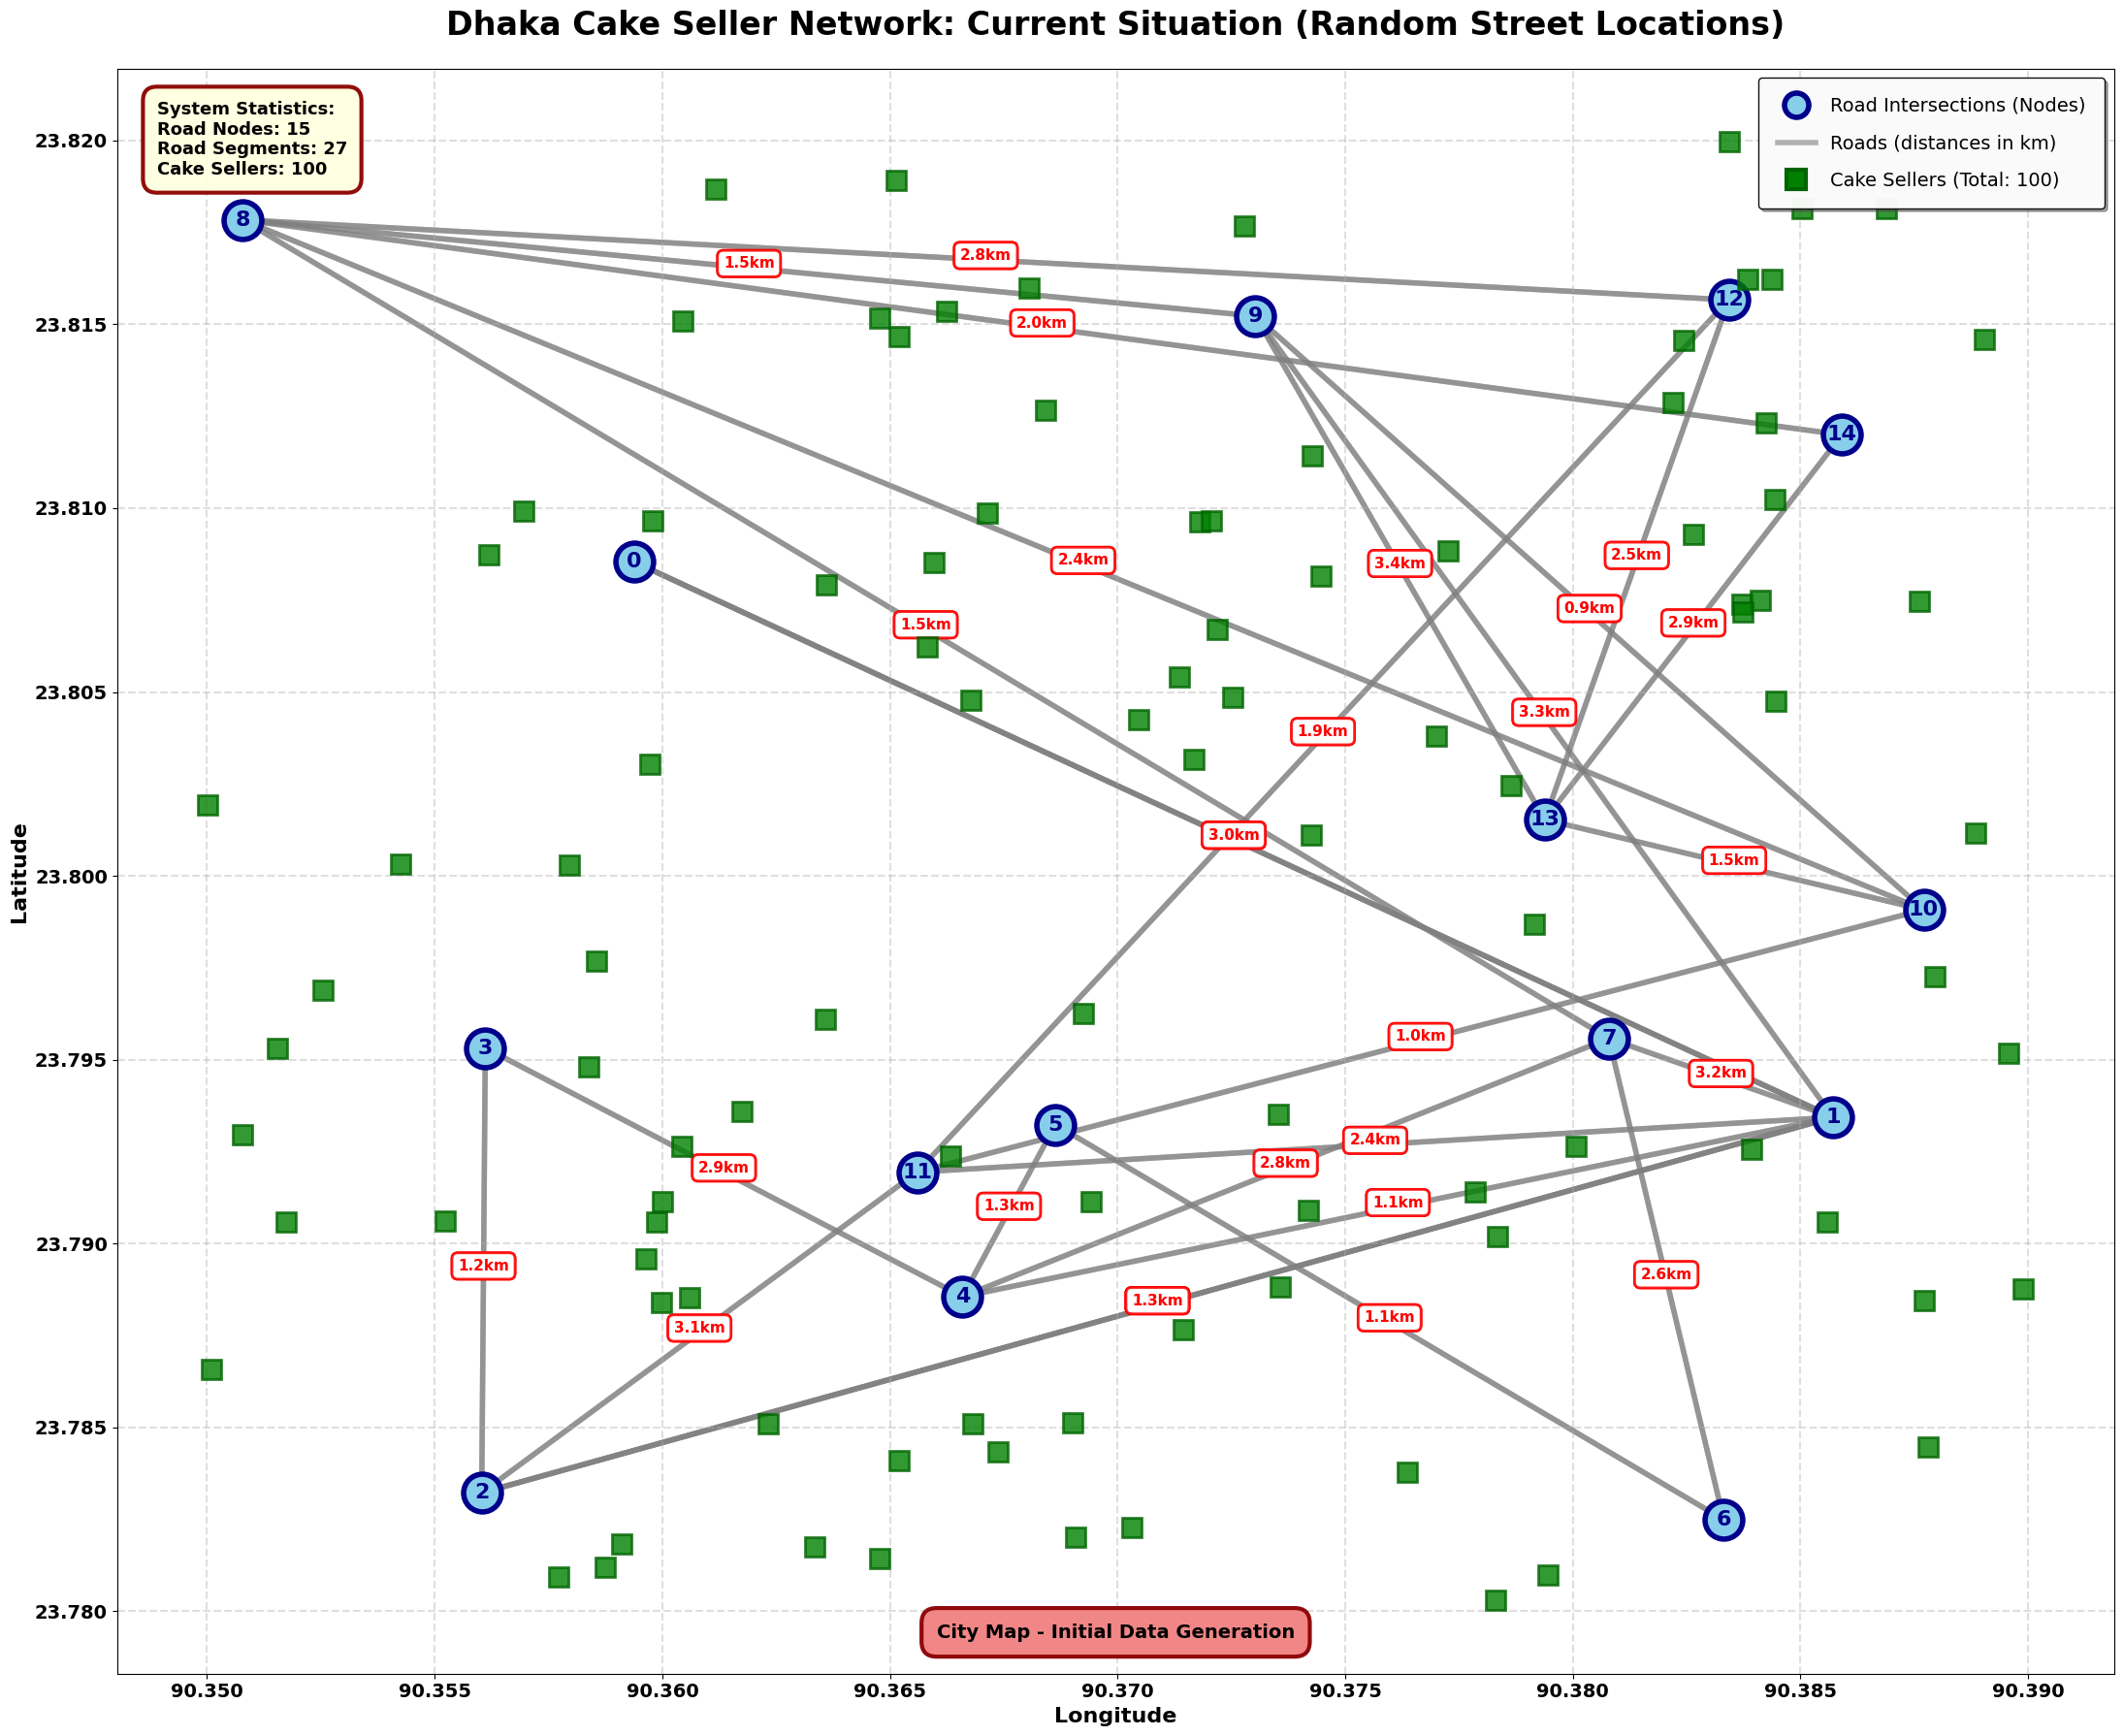

  Map window opened

DATA GENERATION COMPLETE!

Data Summary:
Generated 100 cake sellers at random street locations
Created road network with 15 nodes and 27 edges
Generated map visualization showing all data points

Data is ready for your project:
• Milestone 1: Sorting and Searching algorithms
• Milestone 2: Zone allocation with capacity constraints for the cake seller
• Milestone 3: Shortest path finder


In [ ]:
import random
import math
import heapq
import matplotlib.pyplot as plt


random.seed(42)


# ==================== DATA GENERATION ====================


def generate_vendor_data(num_vendors=50):
    """Generate random CAKE SELLER data only"""
    vendors = []

    for i in range(1, num_vendors + 1):
        vendor = {
            'id': f'CAKE-{i:03d}',
            'hygiene_score': random.randint(40, 100),
            'experience_years': random.randint(1, 20),
            'monthly_revenue': random.randint(15000, 60000),
            'location': (random.uniform(23.78, 23.82), random.uniform(90.35, 90.39)),
            'type': 'Cake Seller'
        }
        vendors.append(vendor)

    return vendors



def generate_city_graph(num_nodes=15):
    """Generate a weighted graph representing Dhaka's road network"""
    graph = {i: [] for i in range(num_nodes)}

    for i in range(num_nodes - 1):
        weight = random.uniform(0.5, 3.0)
        graph[i].append((i + 1, weight))
        graph[i + 1].append((i, weight))

        if i > 0 and random.random() > 0.5:
            target = random.randint(0, i - 1)
            weight = random.uniform(1.0, 4.0)
            graph[i].append((target, weight))
            graph[target].append((i, weight))

    for _ in range(num_nodes // 2):
        node1 = random.randint(0, num_nodes - 1)
        node2 = random.randint(0, num_nodes - 1)
        if node1 != node2:
            weight = random.uniform(0.8, 3.5)
            edge_exists = False
            for neighbor, _ in graph[node1]:
                if neighbor == node2:
                    edge_exists = True
                    break
            if not edge_exists:
                graph[node1].append((node2, weight))
                graph[node2].append((node1, weight))

    return graph


def generate_node_coordinates(num_nodes=15):
    """Generate 2D coordinates for graph nodes"""
    coordinates = {}
    for i in range(num_nodes):
        coordinates[i] = (random.uniform(23.78, 23.82), random.uniform(90.35, 90.39))
    return coordinates



def visualize_cake_sellers_network(city_graph, node_coordinates, vendors):
    """Create visualization with cake sellers and road network"""

    print("Creating cake seller network visualization...")

    fig, ax = plt.subplots(figsize=(22, 18))

    # Plot edges (roads) - BOLD GRAY LINES
    print("  Drawing roads...")
    for node, neighbors in city_graph.items():
        x1, y1 = node_coordinates[node][1], node_coordinates[node][0]
        for neighbor, weight in neighbors:
            x2, y2 = node_coordinates[neighbor][1], node_coordinates[neighbor][0]
            plt.plot([x1, x2], [y1, y2], 'gray', linewidth=4, alpha=0.6, zorder=1)

            # Add BOLD distance label on roads
            mid_x, mid_y = (x1 + x2) / 2, (y1 + y2) / 2
            plt.text(mid_x, mid_y, f'{weight:.1f}km', fontsize=11,
                    color='red', ha='center', fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                             alpha=0.85, edgecolor='red', linewidth=2))

    # Plot nodes (intersections) - LARGER AND BOLDER
    print("  Drawing intersections...")
    for node, coord in node_coordinates.items():
        plt.plot(coord[1], coord[0], 'o', markersize=28,
                color='skyblue', markeredgecolor='darkblue',
                markeredgewidth=4, zorder=3)
        plt.text(coord[1], coord[0], str(node), fontsize=16,
                ha='center', va='center', fontweight='bold',
                color='darkblue', zorder=4)

    # Plot ALL CAKE SELLERS (no mapping lines, just points)
    print("  Drawing cake seller locations...")
    for v in vendors:
        plt.plot(v['location'][1], v['location'][0], 's',
                markersize=15, color='green', markeredgecolor='darkgreen',
                markeredgewidth=2, zorder=5, alpha=0.8)

    # Create legend with BOLD styling
    from matplotlib.lines import Line2D

    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='skyblue',
               markersize=18, markeredgecolor='darkblue', markeredgewidth=4,
               label='Road Intersections (Nodes)', linewidth=0),
        Line2D([0], [0], color='gray', linewidth=4, alpha=0.6,
               label='Roads (distances in km)'),
        Line2D([0], [0], marker='s', color='w', markerfacecolor='green',
               markersize=15, markeredgecolor='darkgreen', markeredgewidth=3,
               label=f'Cake Sellers (Total: {len(vendors)})', linewidth=0),
    ]

    plt.legend(handles=legend_elements, loc='upper right', fontsize=14,
              framealpha=0.95, edgecolor='black', fancybox=True,
              shadow=True, borderpad=1, labelspacing=1)

    # Add BOLD title and labels with SIZE 16 for axes
    plt.title('Dhaka Cake Seller Network: Current Situation (Random Street Locations)',
             fontsize=24, fontweight='bold', pad=25)

    # X and Y axis labels - BOLD SIZE 16
    plt.xlabel('Longitude', fontsize=16, fontweight='bold')
    plt.ylabel('Latitude', fontsize=16, fontweight='bold')

    # Make axis tick labels BOLD and larger
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)
    for label in ax.get_xticklabels():
        label.set_fontweight('bold')
    for label in ax.get_yticklabels():
        label.set_fontweight('bold')

    plt.grid(True, alpha=0.4, linestyle='--', linewidth=1.5)

    # Add statistics box with BOLD text
    stats_text = 'System Statistics:\n'
    stats_text += f'Road Nodes: {len(city_graph)}\n'
    total_edges = sum(len(neighbors) for neighbors in city_graph.values()) // 2
    stats_text += f'Road Segments: {total_edges}\n'
    stats_text += f'Cake Sellers: {len(vendors)}'

    plt.text(0.02, 0.98, stats_text, transform=ax.transAxes,
            fontsize=13, verticalalignment='top', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.8', facecolor='lightyellow',
                     alpha=0.95, edgecolor='darkred', linewidth=3))

    # Add City Map label at bottom
    plt.text(0.5, 0.02, "City Map - Initial Data Generation", transform=ax.transAxes,
            fontsize=14, ha='center', verticalalignment='bottom', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.8', facecolor='lightcoral',
                     alpha=0.95, edgecolor='darkred', linewidth=3))

    plt.tight_layout()

    # Save the figure
    filename = 'cake_sellers_data_visualization.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')

    try:
        plt.show()
        print("  Map window opened")
    except:
        print("  (File saved successfully)")

    plt.close()
    print()

# ==================== MAIN EXECUTION FOR DATA GENERATION AND VISUALIZATION ====================


print("="*70)
print("   DHAKA CAKE SELLER MANAGEMENT SYSTEM  ")
print("="*70)
print()

# Generate data
print("Initializing system... Generating cake seller data...")
vendors = generate_vendor_data(100)  # 100 cake sellers
city_graph = generate_city_graph(15)  # 15 road nodes
node_coordinates = generate_node_coordinates(15)


print(f"Generated {len(vendors)} cake sellers at random locations")
print(f"Loaded city road network with {len(city_graph)} nodes")
print()


# Show cake seller details
print("="*70)
print("SAMPLE CAKE SELLER DATA (First 10)")
print("="*70)
print()


for i, v in enumerate(vendors[:10], 1):
    print(f"{i:2d}. {v['id']} - Hygiene: {v['hygiene_score']:3d}/100 | "
          f"Experience: {v['experience_years']:2d} yrs | Revenue: ৳{v['monthly_revenue']:,}")
    print(f"    Location: ({v['location'][0]:.4f}, {v['location'][1]:.4f})")
    print()


# Show node coordinates
print("="*70)
print("NODE COORDINATES (First 5 Nodes)")
print("="*70)
print()


for node_id in range(5):
    lat, lon = node_coordinates[node_id]
    print(f"Node {node_id}:")
    print(f"  Latitude:  {lat:.6f}")
    print(f"  Longitude: {lon:.6f}")
    print(f"  GPS: ({lat:.4f}, {lon:.4f})")
    print()


# Visualize the network
print("="*70)
print("NETWORK VISUALIZATION")
print("="*70)
print()


visualize_cake_sellers_network(city_graph, node_coordinates, vendors)


# Final summary
print("="*70)
print("DATA GENERATION COMPLETE!")
print("="*70)
print(f"\nData Summary:")
print(f"Generated {len(vendors)} cake sellers at random street locations")
print(f"Created road network with {len(city_graph)} nodes and {sum(len(neighbors) for neighbors in city_graph.values()) // 2} edges")
print(f"Generated map visualization showing all data points")
print()
print("Data is ready for your project:")
print("• Milestone 1: Sorting and Searching algorithms")
print("• Milestone 2: Zone allocation with capacity constraints for the cake seller")
print("• Milestone 3: Shortest path finder")
print("="*70)

# Milestone-1

write your code for milestone-1

In [ ]:
import time
import copy

# ==================== HELPER CLASSES & FUNCTIONS ====================

class SortMetrics:
    def __init__(self, name):
        self.name = name
        self.comparisons = 0
        self.swaps = 0
        self.steps = 0
        self.start_time = 0
        self.end_time = 0

    def start(self):
        self.start_time = time.perf_counter()

    def stop(self):
        self.end_time = time.perf_counter()

    def get_time(self):
        return self.end_time - self.start_time

# --- 1. BUBBLE SORT ---
def bubble_sort(arr, metrics):
    n = len(arr)
    metrics.start()
    for i in range(n):
        for j in range(0, n - i - 1):
            metrics.comparisons += 1
            metrics.steps += 1
            if arr[j]['hygiene_score'] > arr[j + 1]['hygiene_score']:
                arr[j], arr[j + 1] = arr[j + 1], arr[j]
                metrics.swaps += 1
    metrics.stop()
    return arr

# --- 2. INSERTION SORT ---
def insertion_sort(arr, metrics):
    metrics.start()
    for i in range(1, len(arr)):
        key = arr[i]
        j = i - 1
        metrics.steps += 1
        while j >= 0:
            metrics.comparisons += 1
            if key['hygiene_score'] < arr[j]['hygiene_score']:
                arr[j + 1] = arr[j]
                metrics.swaps += 1 # Shift counts as a swap for metric purposes
                j -= 1
                metrics.steps += 1
            else:
                break
        arr[j + 1] = key
    metrics.stop()
    return arr

# --- 3. MERGE SORT ---
def merge_sort(arr, metrics):
    # Wrapper to handle recursion timing
    def _merge_sort_recursive(arr):
        if len(arr) > 1:
            mid = len(arr) // 2
            L = arr[:mid]
            R = arr[mid:]
            metrics.steps += 1

            _merge_sort_recursive(L)
            _merge_sort_recursive(R)

            i = j = k = 0
            while i < len(L) and j < len(R):
                metrics.comparisons += 1
                metrics.steps += 1
                if L[i]['hygiene_score'] < R[j]['hygiene_score']:
                    arr[k] = L[i]
                    i += 1
                else:
                    arr[k] = R[j]
                    j += 1
                metrics.swaps += 1 # Movement counts as swap
                k += 1

            while i < len(L):
                arr[k] = L[i]
                i += 1
                k += 1
                metrics.swaps += 1
                metrics.steps += 1

            while j < len(R):
                arr[k] = R[j]
                j += 1
                k += 1
                metrics.swaps += 1
                metrics.steps += 1

    metrics.start()
    _merge_sort_recursive(arr)
    metrics.stop()
    return arr

# --- 4. QUICK SORT ---
def quick_sort(arr, metrics):
    def _partition(array, low, high):
        pivot = array[high]
        i = low - 1
        for j in range(low, high):
            metrics.comparisons += 1
            metrics.steps += 1
            if array[j]['hygiene_score'] <= pivot['hygiene_score']:
                i = i + 1
                array[i], array[j] = array[j], array[i]
                metrics.swaps += 1
        array[i + 1], array[high] = array[high], array[i + 1]
        metrics.swaps += 1
        return i + 1

    def _quick_sort_recursive(array, low, high):
        if low < high:
            pi = _partition(array, low, high)
            metrics.steps += 1
            _quick_sort_recursive(array, low, pi - 1)
            _quick_sort_recursive(array, pi + 1, high)

    metrics.start()
    _quick_sort_recursive(arr, 0, len(arr) - 1)
    metrics.stop()
    return arr

# --- 5. COUNTING SORT ---
def counting_sort(arr, metrics):
    metrics.start()
    # Hygiene score is 0-100
    max_score = 100
    count = [0] * (max_score + 1)
    output = [None] * len(arr)

    # Store count of each character
    for i in range(len(arr)):
        count[arr[i]['hygiene_score']] += 1
        metrics.steps += 1

    # Change count[i] so that count[i] now contains actual
    # position of this digit in output array
    for i in range(1, 101):
        count[i] += count[i - 1]
        metrics.steps += 1

    # Build the output array
    i = len(arr) - 1
    while i >= 0:
        output[count[arr[i]['hygiene_score']] - 1] = arr[i]
        count[arr[i]['hygiene_score']] -= 1
        i -= 1
        metrics.swaps += 1 # Movement to output array
        metrics.steps += 1

    for i in range(len(arr)):
        arr[i] = output[i]

    metrics.stop()
    # Counting sort doesn't do standard comparisons
    return arr

# --- SEARCH ALGORITHM (Linear) ---
def linear_search_vendor(vendors, target_id):
    comparisons = 0
    for vendor in vendors:
        comparisons += 1
        if vendor['id'] == target_id:
            return vendor, comparisons
    return None, comparisons

# ==================== EXECUTION ====================

print(f"MILESTONE 1: SORTING & SEARCHING CAKE SELLERS")
print(f"PART A: SORTING BY HYGIENE SCORE")
print(f"Testing 5 sorting algorithms with {len(vendors)} vendors...")

algorithms = [
    ("Bubble Sort", bubble_sort),
    ("Insertion Sort", insertion_sort),
    ("Merge Sort", merge_sort),
    ("Quick Sort", quick_sort),
    ("Counting Sort", counting_sort)
]

print("\nALGORITHM PERFORMANCE COMPARISON TABLE [cite: 19]")
print("="*80)
print(f"{'Algorithm':<20} | {'Time (sec)':<12} | {'Comparisons':<12} | {'Swaps':<10} | {'Steps':<10}")
print("-" * 80)

# Keep a sorted copy for later use
sorted_vendors_final = []

for name, func in algorithms:
    # Create a fresh copy for each sort so data isn't pre-sorted
    data_copy = copy.deepcopy(vendors)
    m = SortMetrics(name)

    # Run Sort
    sorted_data = func(data_copy, m)

    # Save the result of the most efficient one (usually quick or merge) for next steps
    if name == "Quick Sort":
        sorted_vendors_final = sorted_data

    print(f"{name:<20} | {m.get_time():<12.6f} | {m.comparisons:<12} | {m.swaps:<10} | {m.steps:<10}")

print("\n")
print(f"PART B: SEARCH CAKE SELLER BY ID [cite: 51]")
search_id = input("Enter Vendor ID to search (e.g., CAKE-057): ") or "CAKE-057" # Default for demo
print(f"Searching for: {search_id}")

result, comps = linear_search_vendor(vendors, search_id)

if result:
    print("FOUND!")
    print("Cake Seller Details:")
    print(f"ID: {result['id']}")
    print(f"Hygiene Score: {result['hygiene_score']}/100")
    print(f"Experience: {result['experience_years']} years")
    print(f"Monthly Revenue: ৳{result['monthly_revenue']:,}")
    print(f"Location (GPS): ({result['location'][0]:.4f}, {result['location'][1]:.4f})")
else:
    print("Vendor not found.")

MILESTONE 1: SORTING & SEARCHING CAKE SELLERS
PART A: SORTING BY HYGIENE SCORE
Testing 5 sorting algorithms with 100 vendors...

ALGORITHM PERFORMANCE COMPARISON TABLE [cite: 19]
Algorithm            | Time (sec)   | Comparisons  | Swaps      | Steps     
--------------------------------------------------------------------------------
Bubble Sort          | 0.000995     | 4950         | 2383       | 4950      
Insertion Sort       | 0.000565     | 2479         | 2383       | 2482      
Merge Sort           | 0.000243     | 539          | 672        | 771       
Quick Sort           | 0.000181     | 682          | 407        | 750       
Counting Sort        | 0.000045     | 0            | 100        | 300       


PART B: SEARCH CAKE SELLER BY ID [cite: 51]
Enter Vendor ID to search (e.g., CAKE-057): CAKE-057
Searching for: CAKE-057
FOUND!
Cake Seller Details:
ID: CAKE-057
Hygiene Score: 98/100
Experience: 17 years
Monthly Revenue: ৳25,317
Location (GPS): (23.7823, 90.3703)


# Milestone-2

write your code for milestone-2

MILESTONE 2: ALLOCATING CAKE SELLERS TO NODES (Capacity: 5 per node)
--------------------------------------------------------------------------------
✓ Successfully allocated: 75 cake sellers
⚠ Waitlisted (no capacity): 25 cake sellers
  (System Total Capacity: 75)

NODE OCCUPANCY SUMMARY:
----------------------------------------------------------------------------------------------------
Node ID    Allocated    Capacity   Status     Seller IDs
----------------------------------------------------------------------------------------------------
0          5            5          FULL       CAKE-001, CAKE-006, CAKE-019, CAKE-021, CAKE-037
1          5            5          FULL       CAKE-015, CAKE-018, CAKE-022, CAKE-063, CAKE-069
2          5            5          FULL       CAKE-003, CAKE-011, CAKE-032, CAKE-052, CAKE-061
3          5            5          FULL       CAKE-008, CAKE-013, CAKE-024, CAKE-029, CAKE-030
4          5            5          FULL       CAKE-007, CAKE-035, CAKE

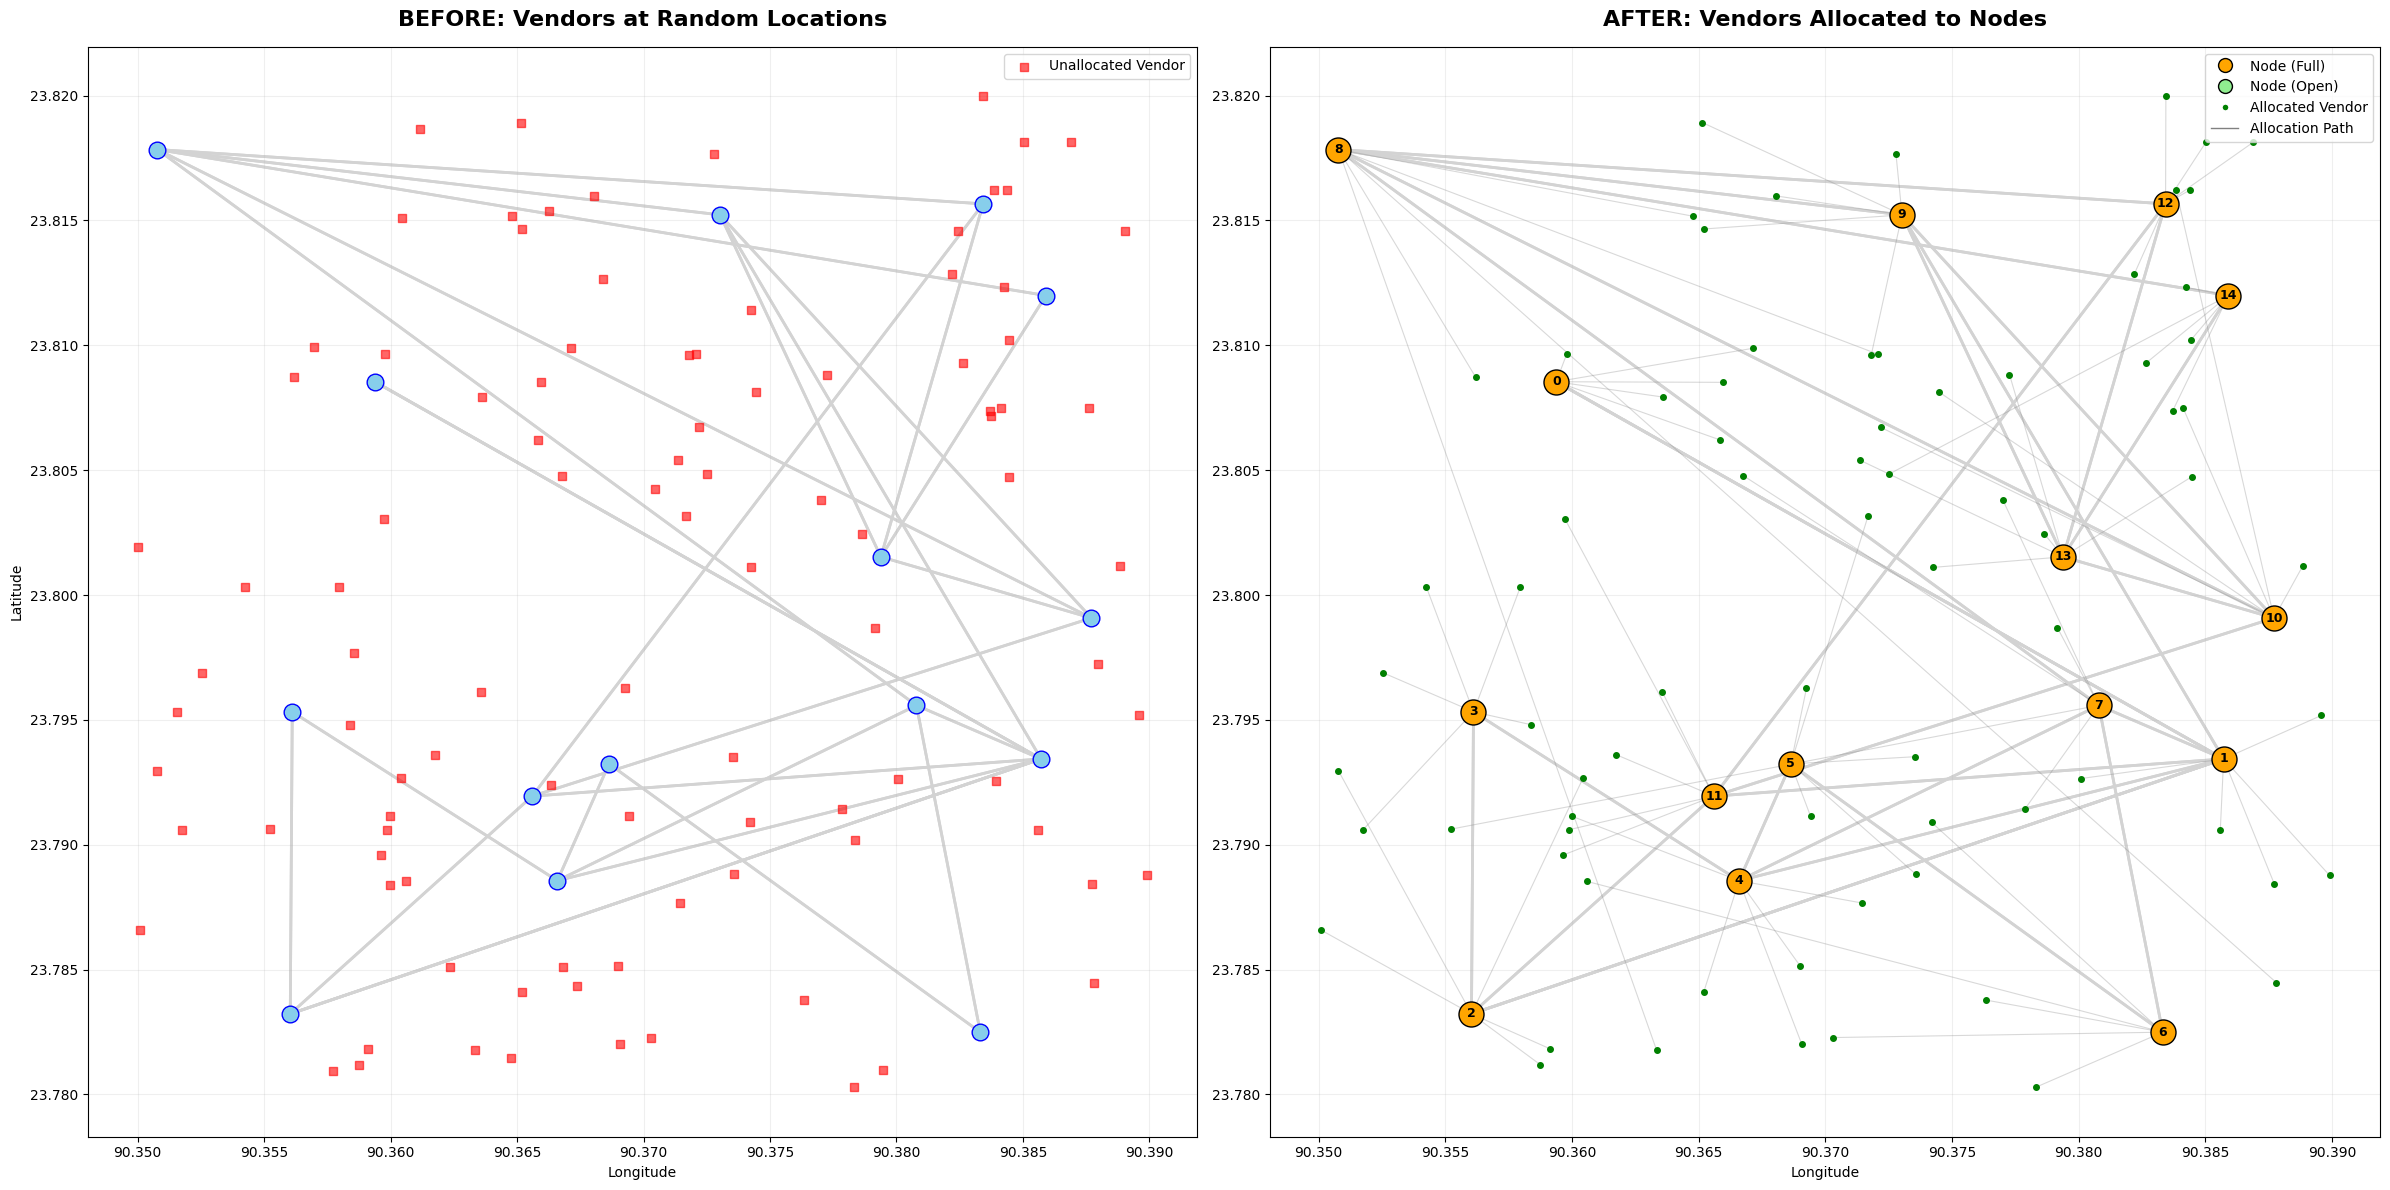

In [ ]:
import math
import matplotlib.pyplot as plt

# ==============================================================================
# 1. HELPER FUNCTIONS
# ==============================================================================

def calculate_distance(coord1, coord2):
    """Calculates Euclidean distance between two (lat, lon) points."""
    return math.sqrt((coord1[0] - coord2[0])**2 + (coord1[1] - coord2[1])**2)

def allocate_vendors(vendors_list, nodes_map, max_capacity=5):
    """
    Allocates vendors to the nearest node with available capacity.
    Returns:
        - allocations: Dictionary {node_id: [vendor_list]}
        - waitlist: List of vendors that couldn't be assigned
    """
    # Initialize data structures
    allocations = {node_id: [] for node_id in nodes_map.keys()}
    waitlist = []

    # Process each vendor
    for vendor in vendors_list:
        vendor_loc = vendor['location']

        # 1. Calculate distance to ALL nodes
        # Creates a list of tuples: (distance, node_id)
        distance_options = []
        for node_id, node_loc in nodes_map.items():
            dist = calculate_distance(vendor_loc, node_loc)
            distance_options.append((dist, node_id))

        # 2. Sort nodes by distance (Nearest -> Farthest)
        distance_options.sort(key=lambda x: x[0])

        # 3. Attempt assignment based on capacity constraints
        assigned = False
        for _, node_id in distance_options:
            # Check if this node has space
            if len(allocations[node_id]) < max_capacity:
                # Assign vendor to this node
                # We create a copy to ensure we don't mutate the original list unexpectedly
                vendor_assigned = vendor.copy()
                vendor_assigned['assigned_node'] = node_id
                allocations[node_id].append(vendor_assigned)
                assigned = True
                break # Stop looking for nodes for this vendor

        # 4. If no node had space, add to waitlist
        if not assigned:
            waitlist.append(vendor)

    return allocations, waitlist

# ==============================================================================
# 2. BONUS VISUALIZATION (BEFORE VS AFTER)
# ==============================================================================

def plot_allocation_comparison(city_graph, node_coords, raw_vendors, allocated_data):
    """
    Plots two maps side-by-side:
    1. Before: Random distribution.
    2. After: Vendors allocated to specific nodes.
    """
    fig, axes = plt.subplots(1, 2, figsize=(24, 12))

    # --- PLOT 1: BEFORE (Random Locations) ---
    ax1 = axes[0]
    ax1.set_title("BEFORE: Vendors at Random Locations", fontsize=16, fontweight='bold', pad=15)

    # Draw Roads
    for node, neighbors in city_graph.items():
        x1, y1 = node_coords[node][1], node_coords[node][0]
        for neighbor, _ in neighbors:
            x2, y2 = node_coords[neighbor][1], node_coords[neighbor][0]
            ax1.plot([x1, x2], [y1, y2], color='lightgray', linewidth=2, zorder=1)

    # Draw Nodes
    for n, c in node_coords.items():
        ax1.plot(c[1], c[0], 'o', markersize=12, color='skyblue', markeredgecolor='blue', zorder=2)

    # Draw Vendors (Red Squares)
    vx = [v['location'][1] for v in raw_vendors]
    vy = [v['location'][0] for v in raw_vendors]
    ax1.scatter(vx, vy, c='red', marker='s', s=30, alpha=0.6, zorder=3, label='Unallocated Vendor')

    ax1.set_xlabel("Longitude")
    ax1.set_ylabel("Latitude")
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.2)

    # --- PLOT 2: AFTER (Allocated to Nodes) ---
    ax2 = axes[1]
    ax2.set_title("AFTER: Vendors Allocated to Nodes", fontsize=16, fontweight='bold', pad=15)

    # Draw Roads
    for node, neighbors in city_graph.items():
        x1, y1 = node_coords[node][1], node_coords[node][0]
        for neighbor, _ in neighbors:
            x2, y2 = node_coords[neighbor][1], node_coords[neighbor][0]
            ax2.plot([x1, x2], [y1, y2], color='lightgray', linewidth=2, zorder=1)

    # Draw Allocations
    for node_id, vendor_list in allocated_data.items():
        nx, ny = node_coords[node_id][1], node_coords[node_id][0]

        # Color node: Orange if full (5 vendors), Green if available space
        node_color = 'orange' if len(vendor_list) >= 5 else '#90EE90'

        # Plot Node
        ax2.plot(nx, ny, 'o', markersize=18, color=node_color, markeredgecolor='black', zorder=4)
        ax2.text(nx, ny, str(node_id), ha='center', va='center', fontsize=9, fontweight='bold', zorder=5)

        # Draw lines from Original Location -> Assigned Node
        for v in vendor_list:
            vx, vy = v['location'][1], v['location'][0]
            # Connection line
            ax2.plot([vx, nx], [vy, ny], '-', color='gray', alpha=0.3, linewidth=0.8, zorder=2)
            # Vendor dot
            ax2.plot(vx, vy, '.', markersize=8, color='green', zorder=3)

    ax2.set_xlabel("Longitude")

    # Custom Legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='orange', label='Node (Full)', markersize=10, markeredgecolor='black'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#90EE90', label='Node (Open)', markersize=10, markeredgecolor='black'),
        Line2D([0], [0], marker='.', color='w', markerfacecolor='green', label='Allocated Vendor', markersize=10),
        Line2D([0], [0], color='gray', lw=1, label='Allocation Path'),
    ]
    ax2.legend(handles=legend_elements, loc='upper right')
    ax2.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()

# ==============================================================================
# 3. MAIN EXECUTION BLOCK
# ==============================================================================

print("MILESTONE 2: ALLOCATING CAKE SELLERS TO NODES (Capacity: 5 per node)")
print("-" * 80)

# 1. Run the allocation algorithm
# Note: 'vendors' and 'node_coordinates' come from the Data Generation cell
final_allocations, waitlisted_vendors = allocate_vendors(vendors, node_coordinates)

# 2. Display Summary Statistics
total_capacity = len(node_coordinates) * 5
allocated_count = len(vendors) - len(waitlisted_vendors)

print(f"✓ Successfully allocated: {allocated_count} cake sellers")
print(f"⚠ Waitlisted (no capacity): {len(waitlisted_vendors)} cake sellers")
print(f"  (System Total Capacity: {total_capacity})")
print("\nNODE OCCUPANCY SUMMARY:")
print("-" * 100)
print(f"{'Node ID':<10} {'Allocated':<12} {'Capacity':<10} {'Status':<10} {'Seller IDs'}")
print("-" * 100)

# 3. Print detailed table
for node_id in sorted(final_allocations.keys()):
    assigned_list = final_allocations[node_id]
    count = len(assigned_list)
    status = "FULL" if count == 5 else "OPEN"

    # Get list of IDs for display
    ids = [v['id'] for v in assigned_list]
    ids_str = ", ".join(ids)

    print(f"{node_id:<10} {count:<12} {5:<10} {status:<10} {ids_str}")

print("-" * 100)
print("\nGenerating Bonus Visualization...")

# 4. Run Bonus Visualization
plot_allocation_comparison(city_graph, node_coordinates, vendors, final_allocations)

# Milestone-3

write your code for milestone-3

MILESTONE 3: SHORTEST PATH OPTIMIZATION

Available nodes: 0 to 14
Where are you currently located? (Enter node number): 2

You are at Node 2
Coordinates: (23.78322310630631, 90.35603322632052)

--- Sample Cake Sellers ---
1. CAKE-001 -> Located at Node 0 (Hygiene: 80/100)
2. CAKE-002 -> Located at Node 9 (Hygiene: 48/100)
3. CAKE-003 -> Located at Node 2 (Hygiene: 77/100)
4. CAKE-004 -> Located at Node 13 (Hygiene: 72/100)
5. CAKE-005 -> Located at Node 5 (Hygiene: 84/100)

Enter Seller ID to visit (e.g., CAKE-001): CAKE-005

Found: CAKE-005
Allocated to: Node 5
Hygiene Score: 84/100
Location: (23.788817624881627, 90.37357062735504)

Calculating shortest route...

>>> SHORTEST ROUTE FOUND!
Route: 2 -> 1 -> 4 -> 5

ROUTE DETAILS:
Start Node: 2
End Node: 5 (CAKE-005)
Number of Stops: 3 segments
Total Distance: 3.6295 km


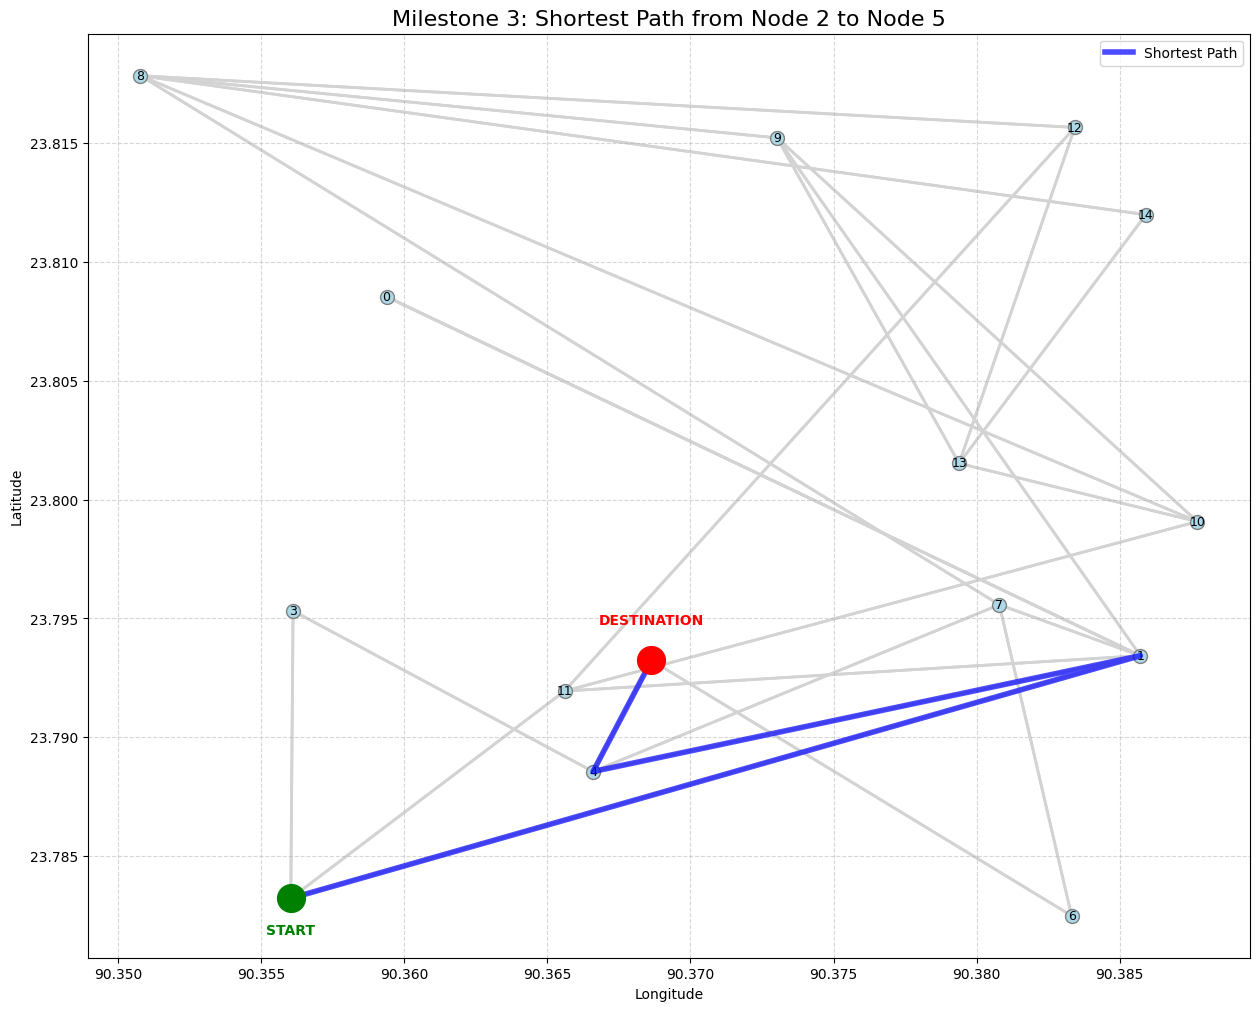

In [ ]:
import random
import math
import heapq
import matplotlib.pyplot as plt

# ==================== 1. PRE-REQUISITE: DATA GENERATION ====================
random.seed(42)

def generate_vendor_data(num_vendors=50):
    vendors = []
    for i in range(1, num_vendors + 1):
        vendor = {
            'id': f'CAKE-{i:03d}',
            'hygiene_score': random.randint(40, 100),
            'experience_years': random.randint(1, 20),
            'monthly_revenue': random.randint(15000, 60000),
            'location': (random.uniform(23.78, 23.82), random.uniform(90.35, 90.39)),
            'type': 'Cake Seller'
        }
        vendors.append(vendor)
    return vendors

def generate_city_graph(num_nodes=15):
    graph = {i: [] for i in range(num_nodes)}
    for i in range(num_nodes - 1):
        weight = random.uniform(0.5, 3.0)
        graph[i].append((i + 1, weight))
        graph[i + 1].append((i, weight))
        if i > 0 and random.random() > 0.5:
            target = random.randint(0, i - 1)
            weight = random.uniform(1.0, 4.0)
            graph[i].append((target, weight))
            graph[target].append((i, weight))
    for _ in range(num_nodes // 2):
        node1 = random.randint(0, num_nodes - 1)
        node2 = random.randint(0, num_nodes - 1)
        if node1 != node2:
            weight = random.uniform(0.8, 3.5)
            edge_exists = False
            for neighbor, _ in graph[node1]:
                if neighbor == node2:
                    edge_exists = True
                    break
            if not edge_exists:
                graph[node1].append((node2, weight))
                graph[node2].append((node1, weight))
    return graph

def generate_node_coordinates(num_nodes=15):
    coordinates = {}
    for i in range(num_nodes):
        coordinates[i] = (random.uniform(23.78, 23.82), random.uniform(90.35, 90.39))
    return coordinates

def calculate_distance(coord1, coord2):
    return math.sqrt((coord1[0] - coord2[0])**2 + (coord1[1] - coord2[1])**2)

def allocate_vendors_to_nodes(vendors, node_coords):
    allocation = {}
    node_occupancy = {node_id: [] for node_id in node_coords}

    for vendor in vendors:
        nearest_node = None
        min_dist = float('inf')

        for node_id, coords in node_coords.items():
            dist = calculate_distance(vendor['location'], coords)
            if dist < min_dist:
                min_dist = dist
                nearest_node = node_id

        allocation[vendor['id']] = nearest_node
        node_occupancy[nearest_node].append(vendor)

    return allocation, node_occupancy

# ==================== 2. MILESTONE 3 ALGORITHM: DIJKSTRA ====================

def dijkstra_shortest_path(graph, start_node, end_node):
    pq = [(0, start_node)]
    distances = {node: float('inf') for node in graph}
    distances[start_node] = 0
    previous_nodes = {node: None for node in graph}

    while pq:
        current_dist, current_node = heapq.heappop(pq)

        if current_node == end_node:
            break

        if current_dist > distances[current_node]:
            continue

        for neighbor, weight in graph[current_node]:
            distance = current_dist + weight
            if distance < distances[neighbor]:
                distances[neighbor] = distance
                previous_nodes[neighbor] = current_node
                heapq.heappush(pq, (distance, neighbor))

    path = []
    current = end_node
    if distances[end_node] == float('inf'):
        return None, float('inf')

    while current is not None:
        path.append(current)
        current = previous_nodes[current]
    path.reverse()

    return path, distances[end_node]

# ==================== 3. VISUALIZATION ====================

def visualize_shortest_path(city_graph, node_coordinates, path, start_node, end_node):
    fig, ax = plt.subplots(figsize=(15, 12))

    # Draw edges
    for node, neighbors in city_graph.items():
        x1, y1 = node_coordinates[node][1], node_coordinates[node][0]
        for neighbor, _ in neighbors:
            x2, y2 = node_coordinates[neighbor][1], node_coordinates[neighbor][0]
            plt.plot([x1, x2], [y1, y2], 'lightgray', linewidth=2, zorder=1)

    # Draw nodes
    for node, coord in node_coordinates.items():
        plt.plot(coord[1], coord[0], 'o', markersize=10, color='lightblue',
                 markeredgecolor='gray', zorder=2)
        plt.text(coord[1], coord[0], str(node), fontsize=9, ha='center', va='center', zorder=3)

    # Highlight Path
    if path:
        path_x = [node_coordinates[node][1] for node in path]
        path_y = [node_coordinates[node][0] for node in path]
        plt.plot(path_x, path_y, color='blue', linewidth=4, alpha=0.7, label='Shortest Path', zorder=4)

        start_coord = node_coordinates[start_node]
        plt.plot(start_coord[1], start_coord[0], 'o', markersize=20, color='green', zorder=5)
        plt.text(start_coord[1], start_coord[0]-0.0015, "START", color='green', fontweight='bold', ha='center', zorder=6)

        end_coord = node_coordinates[end_node]
        plt.plot(end_coord[1], end_coord[0], 'o', markersize=20, color='red', zorder=5)
        plt.text(end_coord[1], end_coord[0]+0.0015, "DESTINATION", color='red', fontweight='bold', ha='center', zorder=6)

    plt.title(f"Milestone 3: Shortest Path from Node {start_node} to Node {end_node}", fontsize=16)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.show()

# ==================== 4. MAIN EXECUTION BLOCK ====================

# 1. Generate Data
vendors = generate_vendor_data(100)
city_graph = generate_city_graph(15)
node_coordinates = generate_node_coordinates(15)

# 2. Run Allocation
vendor_allocation, node_occupancy = allocate_vendors_to_nodes(vendors, node_coordinates)

print("MILESTONE 3: SHORTEST PATH OPTIMIZATION")
print("="*50)

# 3. User Input: Current Location
try:
    print("\nAvailable nodes: 0 to 14")
    current_node = int(input("Where are you currently located? (Enter node number): "))
    if current_node not in city_graph:
        print("Invalid node! Defaulting to Node 0")
        current_node = 0
except ValueError:
    print("Invalid input! Defaulting to Node 0")
    current_node = 0

print(f"\nYou are at Node {current_node}")
print(f"Coordinates: {node_coordinates[current_node]}")

# 4. Display Sample Sellers
print("\n--- Sample Cake Sellers ---")
sample_sellers = list(vendor_allocation.keys())[:5]
for i, sid in enumerate(sample_sellers):
    node = vendor_allocation[sid]
    v_obj = next(v for v in vendors if v['id'] == sid)
    print(f"{i+1}. {sid} -> Located at Node {node} (Hygiene: {v_obj['hygiene_score']}/100)")

# 5. User Input: Target Seller
target_id = input("\nEnter Seller ID to visit (e.g., CAKE-001): ").strip()

if target_id in vendor_allocation:
    target_node = vendor_allocation[target_id]
    target_vendor = next(v for v in vendors if v['id'] == target_id)

    print(f"\nFound: {target_id}")
    print(f"Allocated to: Node {target_node}")
    print(f"Hygiene Score: {target_vendor['hygiene_score']}/100")

    # --- ADDED CODE BELOW ---
    print(f"Location: {target_vendor['location']}")
    # ------------------------

    print("\nCalculating shortest route...")

    # 6. Run Algorithm
    path, distance = dijkstra_shortest_path(city_graph, current_node, target_node)

    if path:
        print(f"\n>>> SHORTEST ROUTE FOUND!")
        path_str = " -> ".join(map(str, path))
        print(f"Route: {path_str}")

        print("\nROUTE DETAILS:")
        print(f"Start Node: {current_node}")
        print(f"End Node: {target_node} ({target_id})")
        print(f"Number of Stops: {len(path) - 1} segments")
        print(f"Total Distance: {distance:.4f} km")

        # 7. Visualize
        visualize_shortest_path(city_graph, node_coordinates, path, current_node, target_node)

    else:
        print("No path found between these nodes.")
else:
    print("Seller ID not found in allocation list.")